# Experiment 4: Neural Network (MLP) Model for YouTube Comment Sentiment Analysis

This notebook mirrors the structure of `experiment_1_baseline_model.ipynb` (Random Forest),
`experiment_2_model_comparison.ipynb` (Logistic Regression, Naive Bayes, Linear SVM, XGBoost),
and `experiment_3_lightgbm_model.ipynb` (LightGBM), but trains a **Multi-Layer Perceptron**
(`MLPClassifier`) — a feed-forward neural network, a different modeling paradigm from the
tree-based and linear models used in the earlier notebooks — on the same `CountVectorizer`
features, and logs the run to MLflow via DagsHub.

In [14]:
# Install any missing dependencies (uncomment if needed)
# %pip install mlflow dagshub scikit-learn pandas numpy matplotlib seaborn

In [15]:
import mlflow
import dagshub

# Same DagsHub-tracked repo used in the earlier experiment notebooks
dagshub.init(repo_owner="MitadruMridha05", repo_name="Youtube_Sentiment_Analysis", mlflow=True)

remote_server_uri = "https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow"
mlflow.set_tracking_uri(remote_server_uri)

Initialized MLflow to track repo "MitadruMridha05/Youtube_Sentiment_Analysis"

Repository MitadruMridha05/Youtube_Sentiment_Analysis initialized!

In [16]:
import numpy as np
import pandas as pd

## Load data

Update `DATA_PATH` to point at your local copy of `youtube_comments_cleaned_final.csv`
(the same file used in the earlier experiment notebooks).

In [17]:
DATA_PATH = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned_final.csv"

df = pd.read_csv(DATA_PATH)
df.shape

(100000, 2)

In [18]:
df["Sentiment"].value_counts()

Sentiment
-1    33475
 1    33473
 0    33052
Name: count, dtype: int64

In [19]:
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neural_network import MLPClassifier

## Feature extraction

Same `CountVectorizer` settings as the earlier notebooks (`max_features=10000`) so this
model is comparable to the baseline and the other models.

In [25]:
vectorizer = CountVectorizer(max_features=10000)

df["CommentText"] = df["CommentText"].fillna("")
x = vectorizer.fit_transform(df['CommentText'])
y = df['Sentiment']

In [21]:
mlflow.set_tracking_uri(remote_server_uri)

In [22]:
mlflow.set_experiment("MLP_model")

<Experiment: artifact_location='mlflow-artifacts:/7e62072db7c24a3e824631ccc0ca21af', creation_time=1789238967364, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1789238967364, lifecycle_stage='active', name='MLP_model', tags={}, trace_location=None, workspace='default'>

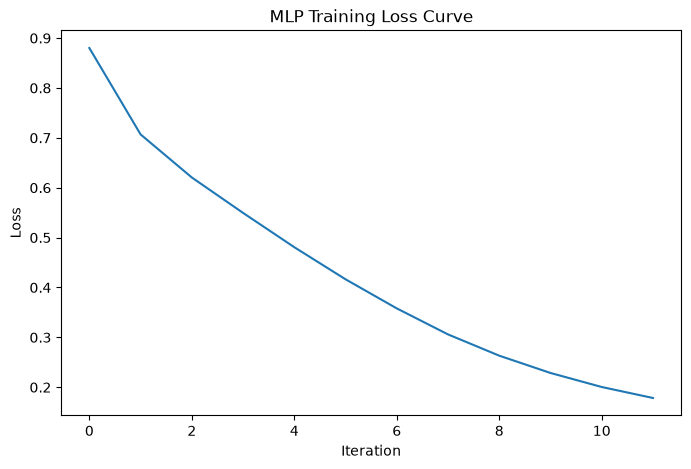

<Figure size 640x480 with 0 Axes>

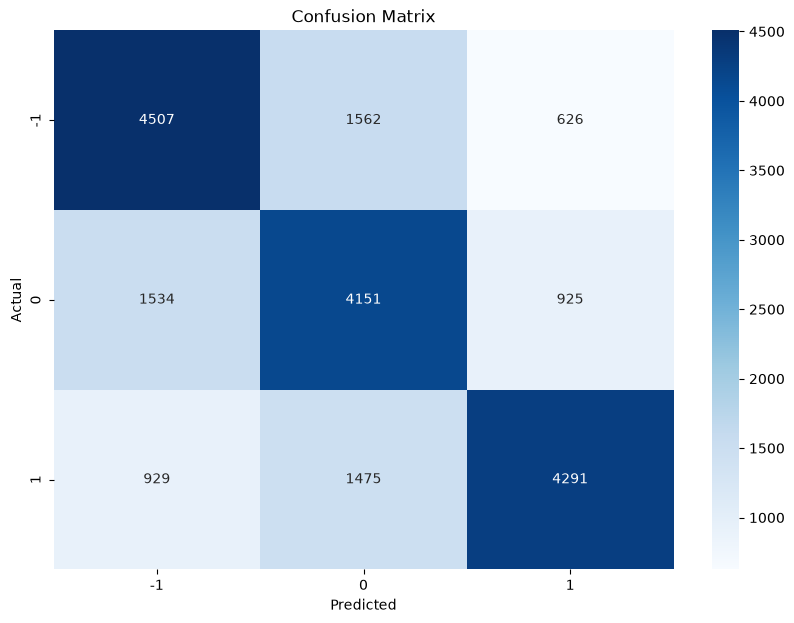

<Figure size 640x480 with 0 Axes>

2026/09/13 00:37:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run respected-goose-583 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/4/runs/4367935935d04351a4ca13a120939255
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/4


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.neural_network._stochastic_optimizers.AdamOptimizer'].

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

with mlflow.start_run():
    #Log a description for the run
    mlflow.set_tag("model_type", "MLPClassifier")
    mlflow.set_tag("experiment", "mlp_model")
    mlflow.set_tag("mlflow_runName", "MLP_model")

    #Add a description
    mlflow.set_tag("description", "Multi-layer perceptron (neural network) model for sentiment analysis on YouTube comments.")

    #Log parameters for vectorizer and model
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    #Log MLP parameters
    hidden_layer_sizes = (100,)
    activation = "relu"
    solver = "adam"
    max_iter = 100
    early_stopping = True

    mlflow.log_param("hidden_layer_sizes", str(hidden_layer_sizes))
    mlflow.log_param("activation", activation)
    mlflow.log_param("solver", solver)
    mlflow.log_param("max_iter", max_iter)
    mlflow.log_param("early_stopping", early_stopping)

    #initialize and train the MLP model
    mlp_model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        early_stopping=early_stopping,
        random_state=42,
    )
    mlp_model.fit(x_train, y_train)

    #Make predictions
    y_pred = mlp_model.predict(x_test)

    #Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if label not in ["accuracy", "macro avg", "weighted avg"]:
            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(f"{label}_{metric_name}", metric_value)

    #Plot the training loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(mlp_model.loss_curve_)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("MLP Training Loss Curve")
    plt.show()

    import os
    artifact_dir = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts"
    os.makedirs(artifact_dir, exist_ok=True)
    loss_curve_path = os.path.join(artifact_dir, "loss_curve_mlp.png")
    plt.savefig(loss_curve_path, bbox_inches="tight")
    mlflow.log_artifact(loss_curve_path, artifact_path="plots")

    #Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    #Save and log the confusion matrix plot
    artifact_path = os.path.join("artifacts", "confusion_matrix_mlp.png")
    plt.savefig(artifact_path, bbox_inches="tight")
    plt.show()

    # Log the saved artifact to MLflow
    mlflow.log_artifact(artifact_path, artifact_path="plots")

print("MLP model training completed and logged to MLflow.")
print(f"Accuracy: {accuracy:.4f}")

In [28]:
# Log the trained model
with mlflow.start_run():
    mlflow.sklearn.log_model(
    mlp_model,
    "mlp_model",
    skops_trusted_types=[
        "sklearn.neural_network._stochastic_optimizers.AdamOptimizer"
    ]
)

2026/09/13 00:43:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run painted-fly-743 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/4/runs/08e109cc53e84bbaa0090d4e1b286fe6
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/4


## Next steps

- Compare this run's accuracy/F1 against the Random Forest, Logistic Regression / Naive Bayes /
  Linear SVM / XGBoost, and LightGBM runs from the earlier notebooks inside the MLflow UI.
- Watch the loss curve for signs of under/overfitting — try a deeper network
  (e.g. `hidden_layer_sizes=(128, 64)`), a different `activation`, or `alpha` (L2 regularization)
  if needed.
- Neural nets are sensitive to feature scale/dimensionality — TF-IDF or a dimensionality
  reduction step (e.g. `TruncatedSVD`) before the MLP could be worth trying.